In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def run_eda(df, target_column=None):

    # -----------------------------------------------------
    # 1. Basic info
    # -----------------------------------------------------
    print("="*60)
    print("BASIC INFO")
    print("="*60)
    print("Shape (rows, columns):", df.shape)
    print("\nColumn data types:\n", df.dtypes)
    print("\nFirst 5 rows:\n", df.head())

    # -----------------------------------------------------
    # 2. Missing values
    # -----------------------------------------------------
    print("\n" + "="*60)
    print("MISSING VALUES")
    print("="*60)
    missing = df.isnull().sum()
    print(missing[missing > 0])
    if missing.sum() == 0:
        print("No missing values found.")

    # -----------------------------------------------------
    # 3. Separate numeric and categorical columns
    # -----------------------------------------------------
    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    categorical_cols = df.select_dtypes(include="object").columns.tolist()

    print("\nNumeric columns:", numeric_cols)
    print("Categorical columns:", categorical_cols)

    # -----------------------------------------------------
    # 4. Summary statistics
    # -----------------------------------------------------
    print("\n" + "="*60)
    print("SUMMARY STATISTICS (numeric columns)")
    print("="*60)
    if numeric_cols:
        print(df[numeric_cols].describe())
    else:
        print("No numeric columns found.")

    print("\n" + "="*60)
    print("SUMMARY STATISTICS (categorical columns)")
    print("="*60)
    if categorical_cols:
        print(df[categorical_cols].describe())
    else:
        print("No categorical columns found.")

    # -----------------------------------------------------
    # 5. Skewness of numeric columns
    # -----------------------------------------------------
    if numeric_cols:
        print("\n" + "="*60)
        print("SKEWNESS (numeric columns)")
        print("="*60)
        print(df[numeric_cols].skew())

    # -----------------------------------------------------
    # 6. Histograms for numeric columns
    # -----------------------------------------------------
    if numeric_cols:
        df[numeric_cols].hist(figsize=(15, 12), bins=20, color="steelblue", edgecolor="black")
        plt.suptitle("Histograms of Numeric Columns")
        plt.tight_layout()
        plt.savefig("eda_histograms.png")
        plt.close()

    # -----------------------------------------------------
    # 7. Boxplots for numeric columns (outlier check)
    # -----------------------------------------------------
    if numeric_cols:
        n_cols = len(numeric_cols)
        plt.figure(figsize=(15, n_cols * 1.2))
        for i, col in enumerate(numeric_cols, 1):
            plt.subplot((n_cols // 3) + 1, 3, i)
            sns.boxplot(x=df[col], color="lightgreen")
            plt.title(col)
        plt.tight_layout()
        plt.savefig("eda_boxplots.png")
        plt.close()

    # -----------------------------------------------------
    # 8. Correlation heatmap (numeric columns only)
    # -----------------------------------------------------
    if len(numeric_cols) > 1:
        plt.figure(figsize=(12, 10))
        sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm")
        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.savefig("eda_correlation_heatmap.png")
        plt.close()

    # -----------------------------------------------------
    # 9. Bar plots for categorical columns (value counts)
    # -----------------------------------------------------
    for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        df[col].value_counts().head(15).plot(kind="bar", color="salmon")
        plt.title(f"Value Counts: {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        safe_name = col.replace(" ", "_")
        plt.savefig(f"eda_barplot_{safe_name}.png")
        plt.close()

    # -----------------------------------------------------
    # 10. Target column distribution (if provided)
    # -----------------------------------------------------
    if target_column is not None and target_column in df.columns:
        print("\n" + "="*60)
        print(f"TARGET COLUMN: {target_column}")
        print("="*60)
        print(df[target_column].describe())

        plt.figure(figsize=(8, 5))
        if target_column in numeric_cols:
            df[target_column].hist(bins=30, color="purple", edgecolor="black")
        else:
            df[target_column].value_counts().plot(kind="bar", color="purple")
        plt.title(f"Target Distribution: {target_column}")
        plt.tight_layout()
        plt.savefig("eda_target_distribution.png")
        plt.close()

    print("\nEDA complete. Plots saved as PNG files in the current folder.")


# ---------------------------------------------------------
# Example usage
# ---------------------------------------------------------
if __name__ == "__main__":
    df = pd.read_csv(r"C:\Users\SSN\Downloads\archive(6)\spambase_csv.csv")
    run_eda(df, target_column="class")

BASIC INFO
Shape (rows, columns): (4601, 58)

Column data types:
 word_freq_make                float64
word_freq_address             float64
word_freq_all                 float64
word_freq_3d                  float64
word_freq_our                 float64
word_freq_over                float64
word_freq_remove              float64
word_freq_internet            float64
word_freq_order               float64
word_freq_mail                float64
word_freq_receive             float64
word_freq_will                float64
word_freq_people              float64
word_freq_report              float64
word_freq_addresses           float64
word_freq_free                float64
word_freq_business            float64
word_freq_email               float64
word_freq_you                 float64
word_freq_credit              float64
word_freq_your                float64
word_freq_font                float64
word_freq_000                 float64
word_freq_money               float64
word_freq_hp          

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

 
target = "class"

df = pd.read_csv(r"C:\Users\SSN\Downloads\archive(6)\spambase_csv.csv")

X_raw = df.drop(columns=[target])
y = df[target]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train_raw.shape)
print("Test shape:", X_test_raw.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (3680, 57)
Test shape: (921, 57)
Train class balance:
 class
0    0.605978
1    0.394022
Name: proportion, dtype: float64
Test class balance:
 class
0    0.605863
1    0.394137
Name: proportion, dtype: float64


In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_values = [10, 15, 20, 30, 45, 57]
k_results = []

for k_test in k_values:
    sel = SelectKBest(score_func=chi2, k=k_test)
    sel.fit(X_train_raw, y_train)
    feats = X_train_raw.columns[sel.get_support()].tolist()

    Xtr_log = np.log1p(X_train_raw[feats])
    Xtr_scaled = StandardScaler().fit_transform(Xtr_log)  # KNN needs scaling, NB didn't

    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=9), 
        Xtr_scaled, 
        y_train, 
        cv=skf, 
        scoring='f1'
    )
    k_results.append({"k": k_test, "Mean F1": scores.mean(), "Std": scores.std()})

k_df = pd.DataFrame(k_results)
print(k_df)

best_k = k_df.loc[k_df["Mean F1"].idxmax(), "k"]
print(f"\nBest k: {best_k}")

    k   Mean F1       Std
0  10  0.878417  0.010606
1  15  0.893730  0.011063
2  20  0.909808  0.008329
3  30  0.908258  0.003775
4  45  0.907957  0.004481
5  57  0.910716  0.006852

Best k: 57


In [4]:
selector = SelectKBest(score_func=chi2, k=best_k)
selector.fit(X_train_raw, y_train)   # fit ONLY on train

selected_features = X_train_raw.columns[selector.get_support()].tolist()

chi2_scores = pd.DataFrame({
    'Feature': X_train_raw.columns,
    'Chi2_Score': selector.scores_,
    'P_Value': selector.pvalues_
}).sort_values(by='Chi2_Score', ascending=False).reset_index(drop=True)

print("Top Selected Features")
print(chi2_scores.head(best_k))
print("\nSelected features:", selected_features)

X_train_sel = X_train_raw[selected_features].copy()
X_test_sel = X_test_raw[selected_features].copy()

Top Selected Features
                       Feature     Chi2_Score        P_Value
0     capital_run_length_total  276446.949698   0.000000e+00
1   capital_run_length_longest  127794.527152   0.000000e+00
2   capital_run_length_average    9371.985727   0.000000e+00
3             word_freq_george    1821.847824   0.000000e+00
4                 word_freq_hp    1241.364742  6.247590e-272
5               word_freq_your     996.112148  1.257032e-218
6               word_freq_free     659.075283  2.373760e-145
7                word_freq_hpl     598.189829  4.145020e-132
8             word_freq_remove     550.290175  1.088593e-121
9                word_freq_000     510.068871  6.126752e-113
10               word_freq_you     496.931119  4.422838e-110
11               char_freq_%21     483.416991  3.856731e-107
12            word_freq_credit     432.935846   3.731697e-96
13                word_freq_3d     383.736756   1.911706e-85
14          word_freq_business     366.056421   1.351592e-81
15

In [5]:
skew_before = X_train_sel.skew().sort_values(ascending=False)
print("Skewness of selected features (train set, BEFORE transform):")
print(skew_before)


Skewness of selected features (train set, BEFORE transform):
char_freq_%23                 35.121082
capital_run_length_longest    31.971596
word_freq_parts               26.762281
word_freq_3d                  25.382222
capital_run_length_average    23.901030
word_freq_table               21.566299
char_freq_%5B                 20.863494
char_freq_%21                 20.363392
word_freq_conference          20.028502
word_freq_project             15.705712
word_freq_85                  15.100827
word_freq_credit              14.688571
word_freq_data                14.224113
word_freq_cs                  14.053797
char_freq_%28                 13.754724
char_freq_%3B                 13.586853
word_freq_money               12.764025
word_freq_telnet              12.699542
word_freq_report              11.776618
word_freq_free                11.683711
char_freq_%24                 11.522217
word_freq_lab                 11.222340
word_freq_font                10.343630
word_freq_857      

In [6]:
X_train_log = np.log1p(X_train_sel)
X_test_log = np.log1p(X_test_sel)

skew_after = X_train_log.skew()

skew_compare = pd.DataFrame({
    'Skew_Before': skew_before[selected_features],
    'Skew_After': skew_after[selected_features],
})

print("Skewness comparison — Before vs After log1p:")
print(skew_compare)


Skewness comparison — Before vs After log1p:
                            Skew_Before  Skew_After
word_freq_make                 5.732918    3.321584
word_freq_address              9.930171    5.898321
word_freq_all                  3.080834    1.696680
word_freq_3d                  25.382222   17.650254
word_freq_our                  4.458956    1.967006
word_freq_over                 6.103469    3.223983
word_freq_remove               7.008064    3.652099
word_freq_internet             6.177419    3.871200
word_freq_order                5.261738    3.292918
word_freq_mail                 9.044361    2.462205
word_freq_receive              5.471354    4.004506
word_freq_will                 2.763601    1.185374
word_freq_people               7.463149    3.657260
word_freq_report              11.776618    5.859581
word_freq_addresses            6.612638    5.719500
word_freq_free                11.683711    3.098847
word_freq_business             5.735952    3.306358
word_freq_email    

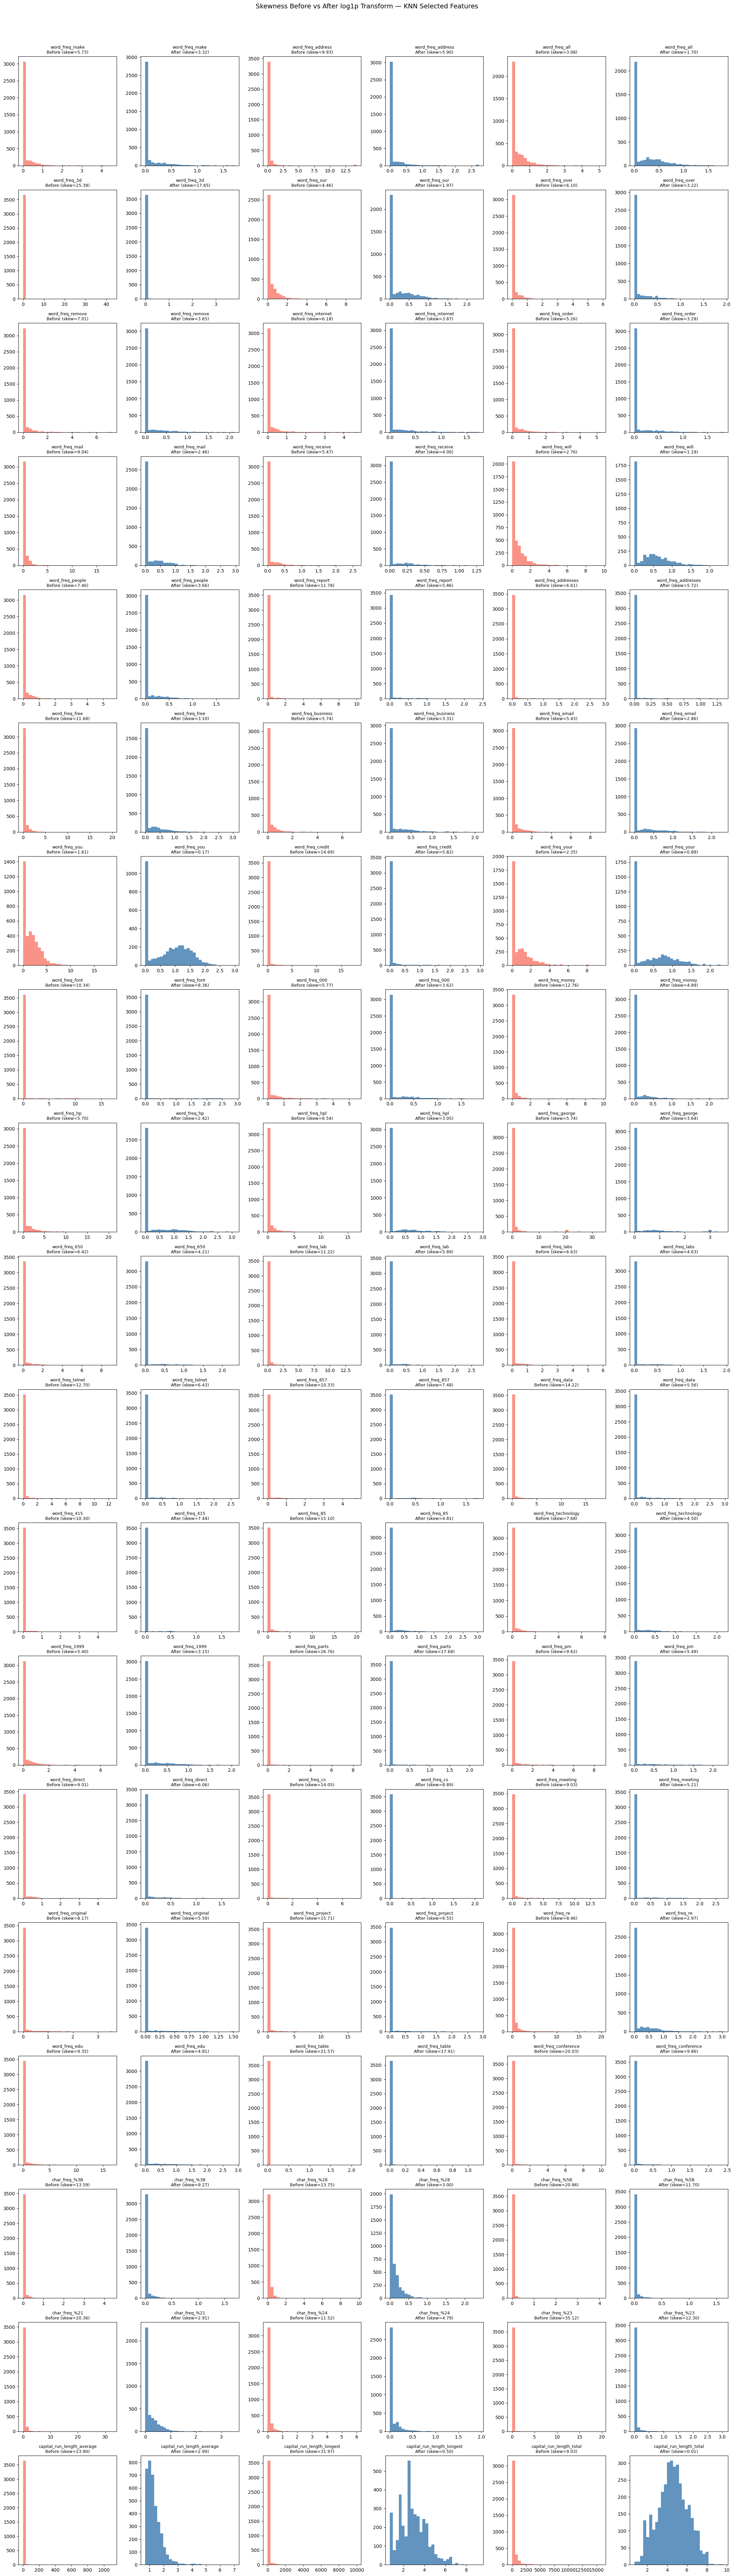

In [7]:
n_features = len(selected_features)
n_cols_pairs = 3
n_rows = int(np.ceil(n_features / n_cols_pairs))

fig, axes = plt.subplots(n_rows, n_cols_pairs * 2, figsize=(22, 4 * n_rows))
for i, feat in enumerate(selected_features):
    row = i // n_cols_pairs
    pair_col = i % n_cols_pairs
    col_before = pair_col * 2
    col_after = pair_col * 2 + 1

    axes[row, col_before].hist(X_train_sel[feat], bins=30, color='salmon', alpha=0.85)
    axes[row, col_before].set_title(f"{feat}\nBefore (skew={skew_before[feat]:.2f})", fontsize=9)

    axes[row, col_after].hist(X_train_log[feat], bins=30, color='steelblue', alpha=0.85)
    axes[row, col_after].set_title(f"{feat}\nAfter (skew={skew_after[feat]:.2f})", fontsize=9)

total_slots = n_rows * n_cols_pairs
for j in range(n_features, total_slots):
    row = j // n_cols_pairs
    pair_col = j % n_cols_pairs
    axes[row, pair_col * 2].axis('off')
    axes[row, pair_col * 2 + 1].axis('off')

fig.suptitle("Skewness Before vs After log1p Transform — KNN Selected Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("knn_skew_before_after_grid.png", dpi=200, bbox_inches='tight')
plt.show()

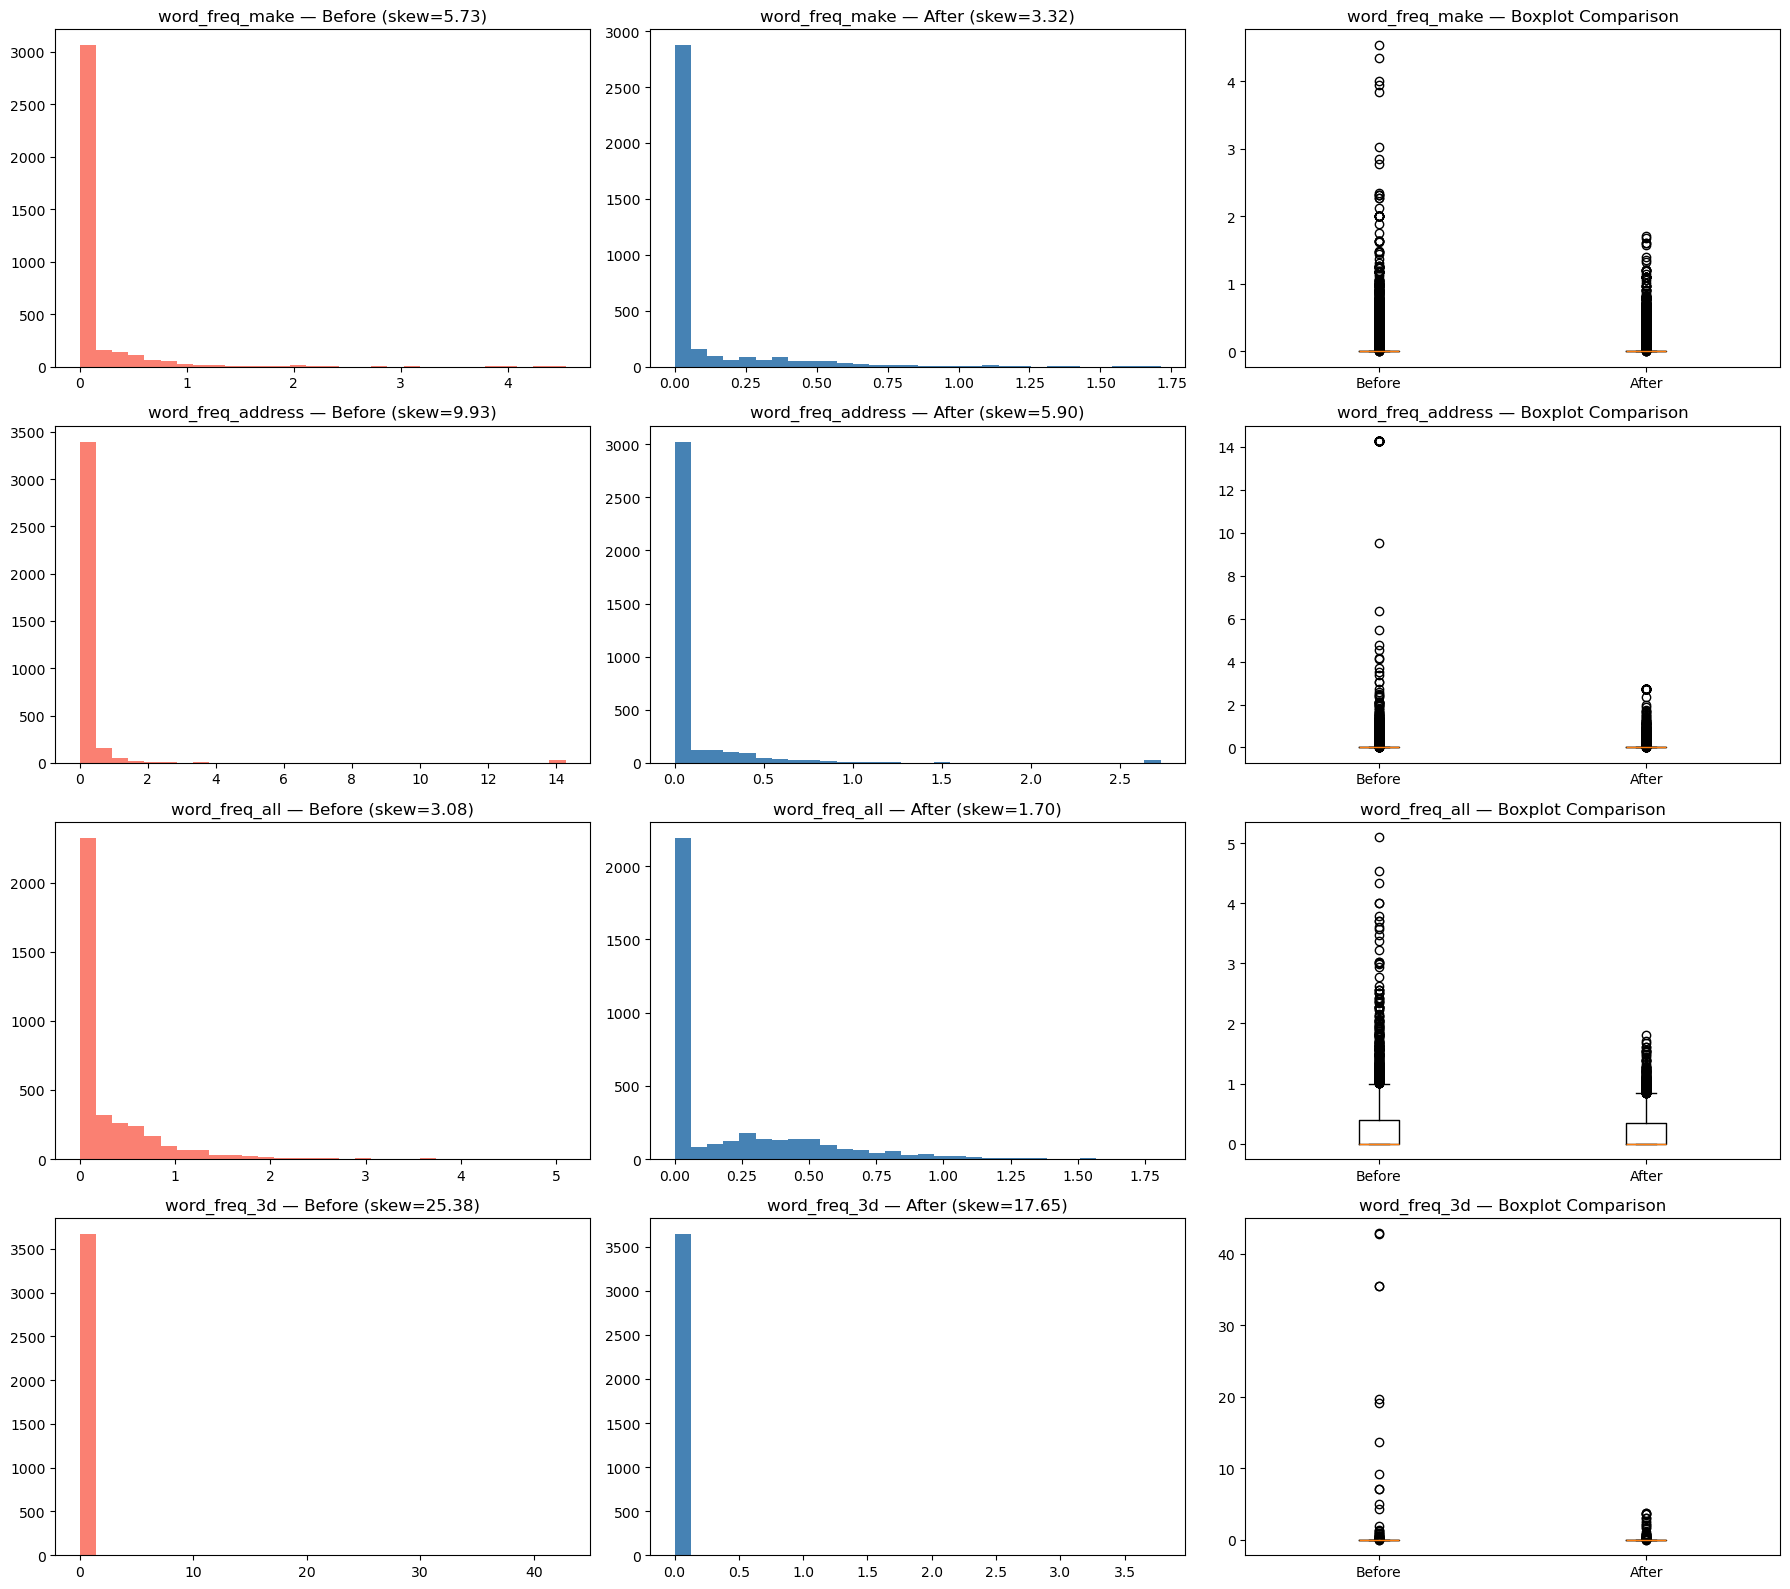

In [8]:
top4 = skew_compare.head(4).index.tolist()

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
for i, feat in enumerate(top4):
    axes[i, 0].hist(X_train_sel[feat], bins=30, color='salmon')
    axes[i, 0].set_title(f"{feat} — Before (skew={skew_before[feat]:.2f})")

    axes[i, 1].hist(X_train_log[feat], bins=30, color='steelblue')
    axes[i, 1].set_title(f"{feat} — After (skew={skew_after[feat]:.2f})")

    axes[i, 2].boxplot([X_train_sel[feat], X_train_log[feat]], tick_labels=['Before', 'After'])
    axes[i, 2].set_title(f"{feat} — Boxplot Comparison")

plt.tight_layout()
plt.savefig("knn_skew_top4_detailed.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
pt = PowerTransformer(method='yeo-johnson')
X_train_pt = pd.DataFrame(
    pt.fit_transform(X_train_sel), 
    columns=selected_features, 
    index=X_train_sel.index
)
X_test_pt = pd.DataFrame(
    pt.transform(X_test_sel), 
    columns=selected_features, 
    index=X_test_sel.index
)

transform_variants = {
    "Raw": X_train_sel,
    "log1p": X_train_log,
    "Yeo-Johnson": X_train_pt
}

skf_t = StratifiedKFold(
    n_splits=5, 
    shuffle=True, 
    random_state=42
)
transform_results = []
for name, Xtr in transform_variants.items():
    Xtr_scaled = StandardScaler().fit_transform(Xtr) 
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=9), 
        Xtr_scaled, 
        y_train, 
        cv=skf_t, 
        scoring='f1'
    )
    transform_results.append({"Transform": name, "Mean F1": scores.mean(), "Std": scores.std()})

print(pd.DataFrame(transform_results))

     Transform   Mean F1       Std
0          Raw  0.873651  0.007419
1        log1p  0.910716  0.006852
2  Yeo-Johnson  0.920673  0.007815


In [10]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_pt), columns=selected_features, index=X_train_pt.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_pt), columns=selected_features, index=X_test_pt.index)

    Algorithm   k   Mean F1       Std
0     kd_tree   3  0.923207  0.012268
1     kd_tree   5  0.918172  0.010738
2     kd_tree   7  0.914147  0.007516
3     kd_tree   9  0.920673  0.007815
4     kd_tree  11  0.919360  0.008776
5     kd_tree  15  0.917940  0.011310
6     kd_tree  21  0.910945  0.011083
7     kd_tree  31  0.905350  0.012061
8   ball_tree   3  0.923207  0.012268
9   ball_tree   5  0.918172  0.010738
10  ball_tree   7  0.914147  0.007516
11  ball_tree   9  0.920673  0.007815
12  ball_tree  11  0.919360  0.008776
13  ball_tree  15  0.917940  0.011310
14  ball_tree  21  0.910945  0.011083
15  ball_tree  31  0.905350  0.012061


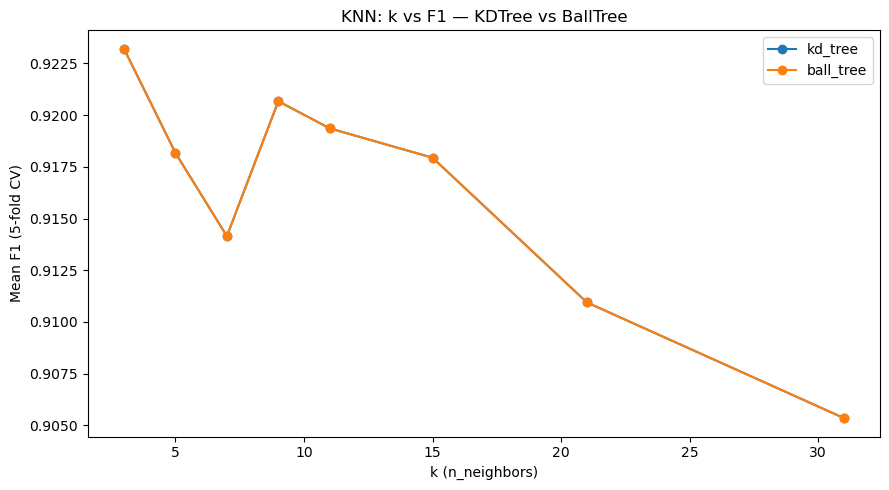

In [11]:
k_neighbors_values = [3, 5, 7, 9, 11, 15, 21, 31]
algorithms = ["kd_tree", "ball_tree"]

knn_results = []
for algo in algorithms:
    for k_n in k_neighbors_values:
        knn = KNeighborsClassifier(n_neighbors=k_n, algorithm=algo)
        scores = cross_val_score(
            knn, 
            X_train_scaled, 
            y_train, 
            cv=skf, 
            scoring='f1'
        )
        knn_results.append({"Algorithm": algo, "k": k_n, "Mean F1": scores.mean(), "Std": scores.std()})

knn_df = pd.DataFrame(knn_results)
print(knn_df)

plt.figure(figsize=(9, 5))
for algo in algorithms:
    subset = knn_df[knn_df["Algorithm"] == algo]
    plt.plot(subset["k"], subset["Mean F1"], marker='o', label=algo)
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean F1 (5-fold CV)")
plt.title("KNN: k vs F1 — KDTree vs BallTree")
plt.legend()
plt.tight_layout()
plt.savefig("knn_neighbors_sweep.png", dpi=200, bbox_inches='tight')
plt.show()

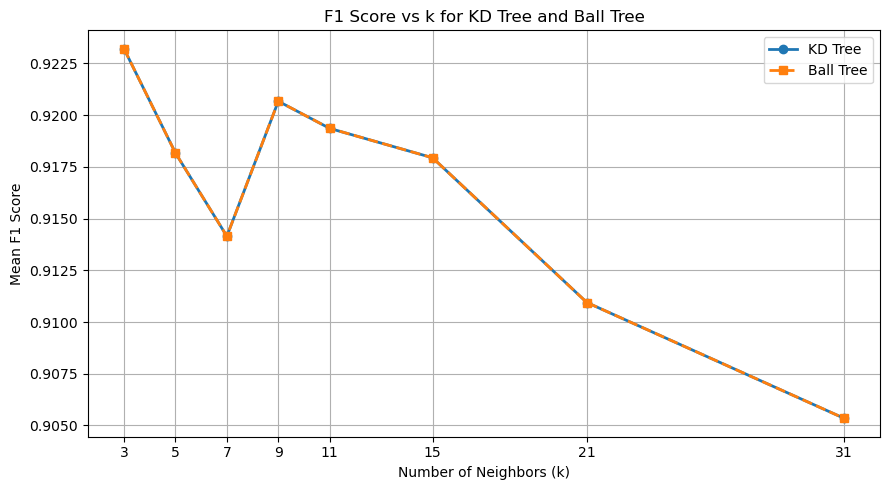

In [12]:
plt.figure(figsize=(9,5))

kd = knn_df[knn_df["Algorithm"] == "kd_tree"]
ball = knn_df[knn_df["Algorithm"] == "ball_tree"]

plt.plot(kd["k"], kd["Mean F1"],
         marker='o',
         linestyle='-',
         linewidth=2,
         label='KD Tree')

plt.plot(ball["k"], ball["Mean F1"],
         marker='s',
         linestyle='--',
         linewidth=2,
         label='Ball Tree')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean F1 Score")
plt.title("F1 Score vs k for KD Tree and Ball Tree")
plt.xticks(k_neighbors_values)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
import time

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'algorithm': ['kd_tree', 'ball_tree']
}

grid_start = time.perf_counter()

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    scoring='f1',
    cv=skf,
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

grid_time = time.perf_counter() - grid_start

print("GridSearchCV best params:", grid.best_params_, "F1:", grid.best_score_)


param_dist_knn = {
    'n_neighbors': list(range(3, 40, 2)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'algorithm': ['kd_tree', 'ball_tree']
}


rand_start = time.perf_counter()

rand = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_dist_knn,
    scoring='f1',
    cv=skf,
    n_iter=30,
    random_state=42,
    n_jobs=-1
)
rand.fit(X_train_scaled, y_train)

rand_time = time.perf_counter() - rand_start

print("RandomizedSearchCV best params:", rand.best_params_, "F1:", rand.best_score_)

best_knn = grid.best_estimator_ if grid.best_score_ >= rand.best_score_ else rand.best_estimator_
print(f"\nSelected: {best_knn}")

GridSearchCV best params: {'algorithm': 'kd_tree', 'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'} F1: 0.9313917104088419
RandomizedSearchCV best params: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'euclidean', 'algorithm': 'kd_tree'} F1: 0.9313917104088419

Selected: KNeighborsClassifier(algorithm='kd_tree', metric='euclidean', n_neighbors=11,
                     weights='distance')


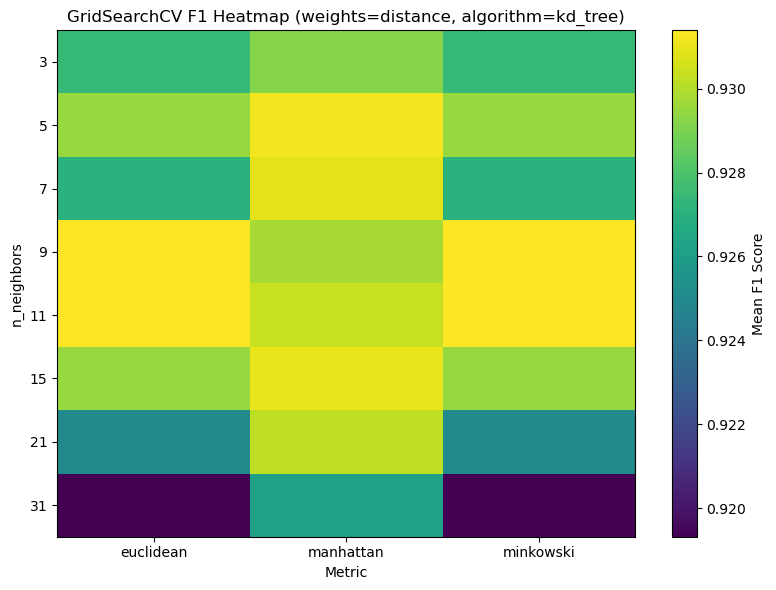

In [26]:
results_df = pd.DataFrame(grid.cv_results_)
best_weights = grid.best_params_['weights']
best_algorithm = grid.best_params_['algorithm']

subset = results_df[
    (results_df['param_weights'] == best_weights) &
    (results_df['param_algorithm'] == best_algorithm)
]

heatmap_data = subset.pivot(index='param_n_neighbors', columns='param_metric', values='mean_test_score')

plt.figure(figsize=(8, 6))
plt.imshow(heatmap_data, cmap='viridis', aspect='auto')
plt.colorbar(label='Mean F1 Score')
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
plt.xlabel("Metric")
plt.ylabel("n_neighbors")
plt.title(f"GridSearchCV F1 Heatmap (weights={best_weights}, algorithm={best_algorithm})")
plt.tight_layout()
plt.show()

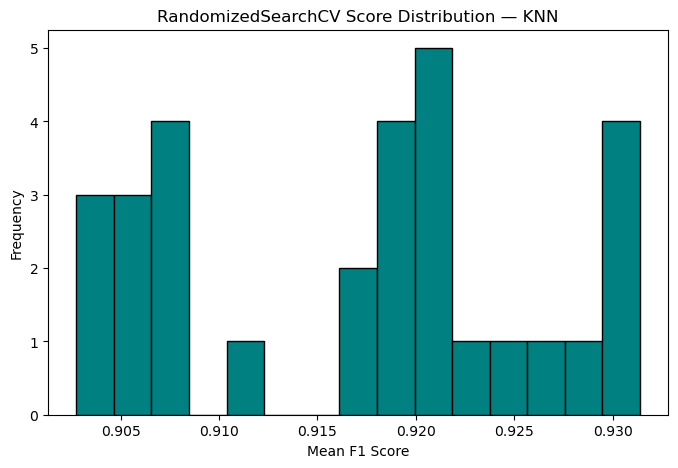

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(rand.cv_results_['mean_test_score'], bins=15, color='teal', edgecolor='black')
plt.xlabel("Mean F1 Score")
plt.ylabel("Frequency")
plt.title("RandomizedSearchCV Score Distribution — KNN")
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

fold_scores = cross_val_score(
    best_knn,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='f1'     
)

fold_results = pd.DataFrame({
    "Fold": np.arange(1, len(fold_scores) + 1),
    "F1 Score": fold_scores
})

print("Fold-wise Cross Validation Scores:")
print(fold_results)

print("\nAverage F1 Score :", fold_scores.mean())
print("Standard Deviation:", fold_scores.std())

Fold-wise Cross Validation Scores:
   Fold  F1 Score
0     1  0.942609
1     2  0.935428
2     3  0.927083
3     4  0.929577
4     5  0.922261

Average F1 Score : 0.9313917104088419
Standard Deviation: 0.007033115766443024


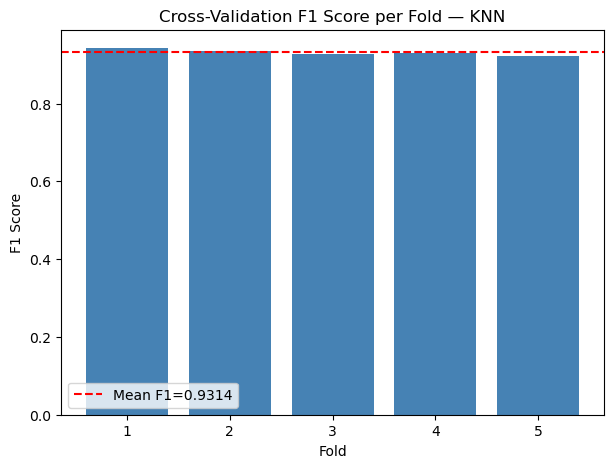

In [24]:
plt.figure(figsize=(7, 5))
plt.bar(fold_results["Fold"], fold_results["F1 Score"], color='steelblue')
plt.axhline(fold_scores.mean(), color='red', linestyle='--', label=f'Mean F1={fold_scores.mean():.4f}')
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("Cross-Validation F1 Score per Fold — KNN")
plt.legend()
plt.show()

Best threshold (max F1 on CV predictions): 0.453
F1 at this threshold: 0.9337 (vs default 0.5)


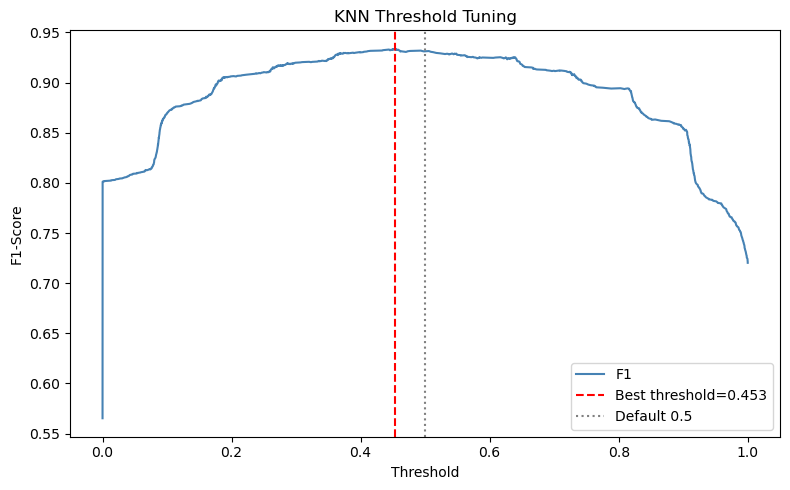

In [15]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

y_proba_cv = cross_val_predict(
    best_knn, 
    X_train_scaled, 
    y_train, 
    cv=skf, 
    method='predict_proba'
)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba_cv)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_thresh_idx = np.argmax(f1_scores[:-1])
best_threshold_knn = thresholds[best_thresh_idx]

print(f"Best threshold (max F1 on CV predictions): {best_threshold_knn:.3f}")
print(f"F1 at this threshold: {f1_scores[best_thresh_idx]:.4f} (vs default 0.5)")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], color='steelblue', label='F1')
plt.axvline(best_threshold_knn, color='red', linestyle='--', label=f'Best threshold={best_threshold_knn:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
plt.xlabel("Threshold"); plt.ylabel("F1-Score")
plt.title("KNN Threshold Tuning")
plt.legend()
plt.tight_layout()
plt.savefig("knn_threshold_tuning.png", dpi=200, bbox_inches='tight')
plt.show()

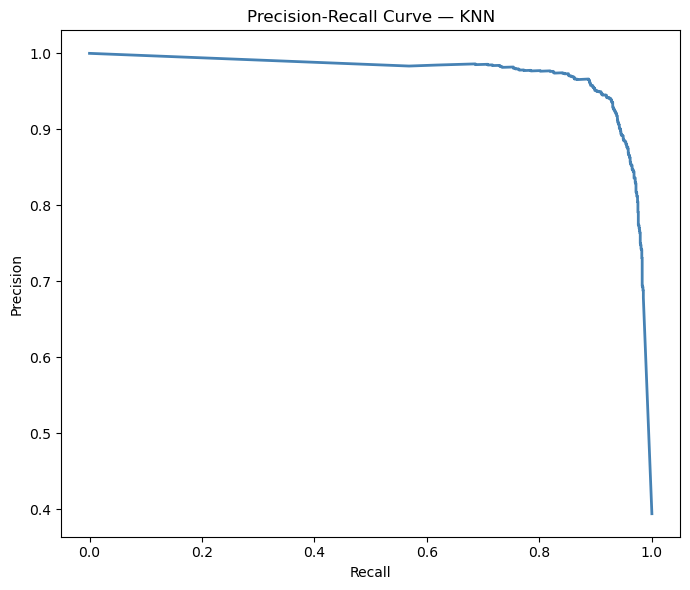

In [16]:
plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, lw=2, color='steelblue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — KNN")
plt.tight_layout()
plt.show()

In [17]:
best_knn.fit(X_train_scaled, y_train)

y_prob_knn = best_knn.predict_proba(X_test_scaled)[:, 1]
y_pred_knn = (y_prob_knn >= best_threshold_knn).astype(int)

report_knn = classification_report(
    y_test, 
    y_pred_knn, 
    output_dict=True, 
    target_names=["Ham (0)", "Spam (1)"]
)
print("="*60)
print("HOLDOUT RESULTS — KNN")
print("="*60)
print(classification_report(
    y_test, 
    y_pred_knn, 
    target_names=["Ham (0)", "Spam (1)"])
)
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

HOLDOUT RESULTS — KNN
              precision    recall  f1-score   support

     Ham (0)       0.95      0.96      0.95       558
    Spam (1)       0.94      0.92      0.93       363

    accuracy                           0.94       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921

ROC-AUC: 0.9749177996978583


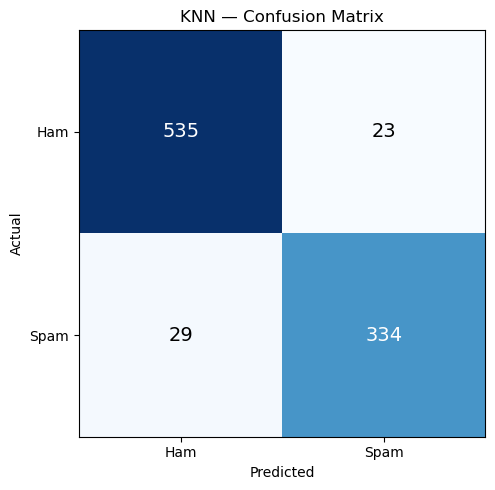

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_knn)
im = ax.imshow(cm, cmap="Blues")
ax.set_title("KNN — Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Ham", "Spam"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Ham", "Spam"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=200, bbox_inches='tight')
plt.show()

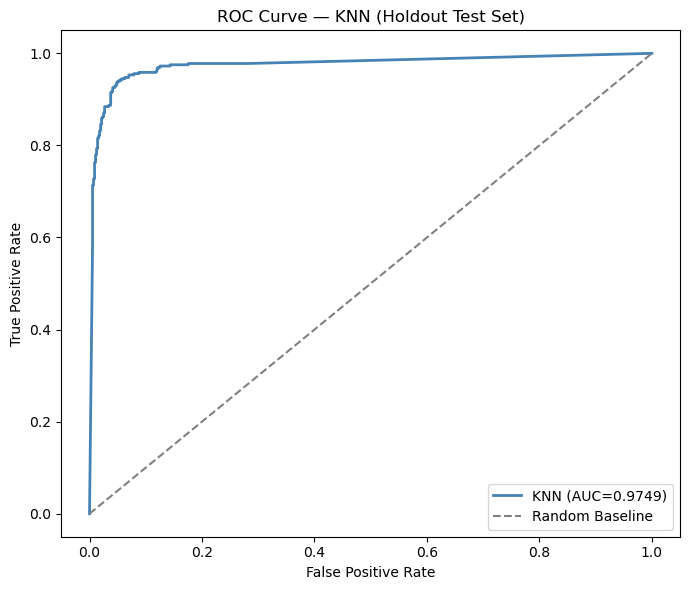

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
auc = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, color='steelblue', label=f"KNN (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN (Holdout Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("knn_roc.png", dpi=300, bbox_inches='tight')
plt.show()

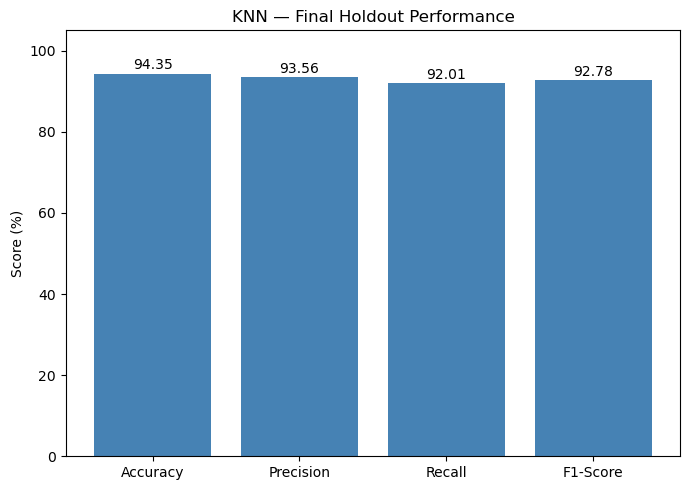

FINAL SUMMARY — KNN
Dataset: Spambase (4601 rows, 57 selected features)
Feature selection: Chi2,, best_k=57
Best hyperparameters: KNeighborsClassifier(algorithm='kd_tree', metric='euclidean', n_neighbors=11,
                     weights='distance')
Best threshold: 0.453
Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
  KNN     94.35      93.56   92.01     92.78     0.97


In [20]:
summary_knn = pd.DataFrame([{
    "Model": "KNN",
    "Accuracy": report_knn["accuracy"] * 100,
    "Precision": report_knn["Spam (1)"]["precision"] * 100,
    "Recall": report_knn["Spam (1)"]["recall"] * 100,
    "F1-Score": report_knn["Spam (1)"]["f1-score"] * 100,
    "ROC-AUC": auc
}]).round(2)

plt.figure(figsize=(7, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
bars = plt.bar(metrics, summary_knn.loc[0, metrics], color='steelblue')
plt.ylim(0, 105)
plt.ylabel("Score (%)")
plt.title("KNN — Final Holdout Performance")
for bar, v in zip(bars, summary_knn.loc[0, metrics]):
    plt.text(bar.get_x() + bar.get_width()/2, v + 1, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.savefig("knn_final_summary.png", dpi=200, bbox_inches='tight')
plt.show()

print("="*60)
print("FINAL SUMMARY — KNN")
print("="*60)
print(f"Dataset: Spambase ({df.shape[0]} rows, {len(selected_features)} selected features)")
print(f"Feature selection: Chi2,, best_k={best_k}")

print(f"Best hyperparameters: {best_knn}")
print(f"Best threshold: {best_threshold_knn:.3f}")
print(summary_knn.to_string(index=False))

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

k_values = [1, 3, 5, 7, 9, 11]
results = []
params = best_knn.get_params()

for k in k_values:

    params["n_neighbors"] = k

    knn = KNeighborsClassifier(**params)
    knn.fit(X_train_scaled, y_train)

    y_prob = knn.predict_proba(X_test_scaled)[:, 1]

    y_pred = (y_prob >= best_threshold_knn).astype(int)

    results.append({
        "K": k,
        "Accuracy (%)": accuracy_score(y_test, y_pred) * 100,
        "Precision (%)": precision_score(y_test, y_pred) * 100,
        "Recall (%)": recall_score(y_test, y_pred) * 100,
        "F1-Score (%)": f1_score(y_test, y_pred) * 100
    })

results_df = pd.DataFrame(results).round(2)

print(results_df)

    K  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
0   1         92.29          91.01       89.26         90.13
1   3         93.38          91.94       91.18         91.56
2   5         94.14          94.52       90.36         92.39
3   7         94.03          93.50       91.18         92.33
4   9         94.14          93.28       91.74         92.50
5  11         94.35          93.56       92.01         92.78


In [22]:
import time
import pandas as pd


start = time.perf_counter()
best_knn.fit(X_train_scaled, y_train)
train_time = time.perf_counter() - start

start = time.perf_counter()
best_knn.predict(X_test_scaled)
prediction_time = time.perf_counter() - start

best_knn_time = pd.DataFrame([{
    "Model": "Best KNN",
    "Training Time (s)": train_time,
    "Prediction Time (s)": prediction_time
}])

print(best_knn_time.round(6))

      Model  Training Time (s)  Prediction Time (s)
0  Best KNN           0.025285             0.249188


In [23]:
import pandas as pd

execution_time_df = pd.DataFrame({
    "Search Method": ["GridSearchCV", "RandomizedSearchCV"],
    "Execution Time (seconds)": [grid_time, rand_time]
}).round(4)

print(execution_time_df)

        Search Method  Execution Time (seconds)
0        GridSearchCV                   40.9411
1  RandomizedSearchCV                   11.2551
